# 11 — English model: baselines and the served classifier

3-class now (`negative` / `neutral` / `positive`), from real star ratings.

Four baselines before the model, same discipline as §5: the transformer-free
bar has to be visible or the final number means nothing. One of them is new and
specific to this dataset — **the auto-sentiment the file already ships**. If we
cannot beat that, there is no reason to train anything.

In [1]:
import sys, json, time
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
from src.normalize import normalize, NORMALIZE_VERSION

SRC = REPO / "dataset for training in ENGLISH" / "df_final_absa_v4.csv"
OUT = REPO / "data_en"; OUT.mkdir(exist_ok=True)
LABELS = ["negative", "neutral", "positive"]

from sklearn.pipeline import make_pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)
import joblib

tr = pd.read_csv(OUT / "train.csv"); calib = pd.read_csv(OUT / "calib.csv")
hold = pd.read_csv(OUT / "hold.csv")
Xtr, ytr = tr.text.fillna("").tolist(), tr.label.values
Xva = pd.concat([calib, hold]).text.fillna("").tolist()
yva = pd.concat([calib, hold]).label.values
print(f"train {len(Xtr):,} | validation {len(Xva):,}")
RESULTS = {}

train 3,523 | validation 1,174


In [2]:
def ev(name, y_true, y_pred, secs=None, note=""):
    acc = accuracy_score(y_true, y_pred); f1 = f1_score(y_true, y_pred, average="macro")
    per = f1_score(y_true, y_pred, average=None, labels=LABELS)
    RESULTS[name] = {"accuracy": round(float(acc), 4), "macro_f1": round(float(f1), 4),
                     **{f"f1_{l}": round(float(v), 4) for l, v in zip(LABELS, per)},
                     "train_seconds": None if secs is None else round(secs, 1), "note": note}
    print(f"{name:<26} acc={acc:.4f}  macroF1={f1:.4f}  " +
          " ".join(f"{l[:3]}={v:.3f}" for l, v in zip(LABELS, per)) +
          (f"  {secs:.1f}s" if secs else ""))

In [3]:
# B1 majority class
ev("majority", yva, DummyClassifier(strategy="most_frequent").fit(Xtr, ytr).predict(Xva))

# B2 the auto-sentiment shipped in the file -- carried through from notebook 10
va_df = pd.concat([calib, hold])
ev("shipped_auto_sentiment", va_df.label.values, va_df.auto.values,
   note="the file's own machine labels, majority-voted per review")

majority                   acc=0.5187  macroF1=0.2277  neg=0.000 neu=0.000 pos=0.683
shipped_auto_sentiment     acc=0.6218  macroF1=0.5460  neg=0.562 neu=0.296 pos=0.780


In [4]:
# B3 TF-IDF word
t0 = time.perf_counter()
w = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
                  LogisticRegression(max_iter=3000, class_weight="balanced")).fit(Xtr, ytr)
ev("tfidf_word", yva, w.predict(Xva), time.perf_counter() - t0)

# B4 TF-IDF word + char  -- the served candidate
t0 = time.perf_counter()
wc = make_pipeline(
    FeatureUnion([("w", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
                  ("c", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                                        min_df=3, sublinear_tf=True))]),
    LogisticRegression(max_iter=4000, class_weight="balanced")).fit(Xtr, ytr)
ev("tfidf_word_char", yva, wc.predict(Xva), time.perf_counter() - t0)

tfidf_word                 acc=0.6593  macroF1=0.6065  neg=0.655 neu=0.376 pos=0.788  1.2s


tfidf_word_char            acc=0.6542  macroF1=0.6019  neg=0.662 neu=0.362 pos=0.782  4.0s


served model: tfidf_word 

              precision    recall  f1-score   support

    negative     0.6243    0.6895    0.6553       306
     neutral     0.3708    0.3822    0.3764       259
    positive     0.8155    0.7619    0.7878       609

    accuracy                         0.6593      1174
   macro avg     0.6035    0.6112    0.6065      1174
weighted avg     0.6675    0.6593    0.6625      1174



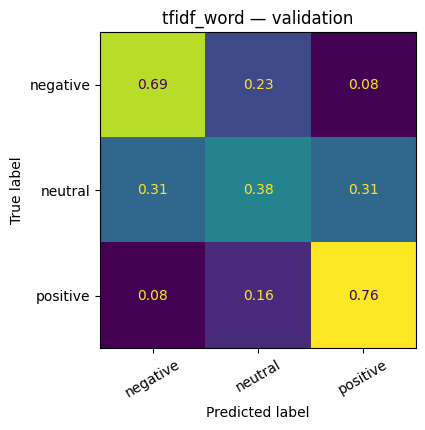

In [5]:
best_name = max(["tfidf_word", "tfidf_word_char"], key=lambda k: RESULTS[k]["macro_f1"])
model = w if best_name == "tfidf_word" else wc
print("served model:", best_name, "\n")
print(classification_report(yva, model.predict(Xva), labels=LABELS, digits=4))

fig, ax = plt.subplots(figsize=(4.4, 4.4))
ConfusionMatrixDisplay.from_predictions(yva, model.predict(Xva), labels=LABELS,
                                        normalize="true", values_format=".2f",
                                        colorbar=False, ax=ax, xticks_rotation=30)
ax.set_title(f"{best_name} — validation")
plt.tight_layout(); plt.savefig(REPO / "data_en" / "fig_confusion.png", dpi=120); plt.show()

In [6]:
mp = OUT / "model_en.joblib"
joblib.dump(model, mp, compress=3)
RESULTS["_served"] = {"name": best_name, "size_mb": round(mp.stat().st_size / 1e6, 2)}
(OUT / "results_model.json").write_text(json.dumps(RESULTS, indent=2), encoding="utf-8")

print(f"{'baseline':<26} {'acc':>7} {'macroF1':>8}")
print("-" * 44)
for k, v in sorted([(k, v) for k, v in RESULTS.items() if not k.startswith("_")],
                   key=lambda kv: kv[1]["macro_f1"]):
    print(f"{k:<26} {v['accuracy']:>7.4f} {v['macro_f1']:>8.4f}")
print(f"\nsaved {mp.name} ({RESULTS['_served']['size_mb']} MB)")

baseline                       acc  macroF1
--------------------------------------------
majority                    0.5187   0.2277
shipped_auto_sentiment      0.6218   0.5460
tfidf_word_char             0.6542   0.6019
tfidf_word                  0.6593   0.6065

saved model_en.joblib (0.58 MB)
